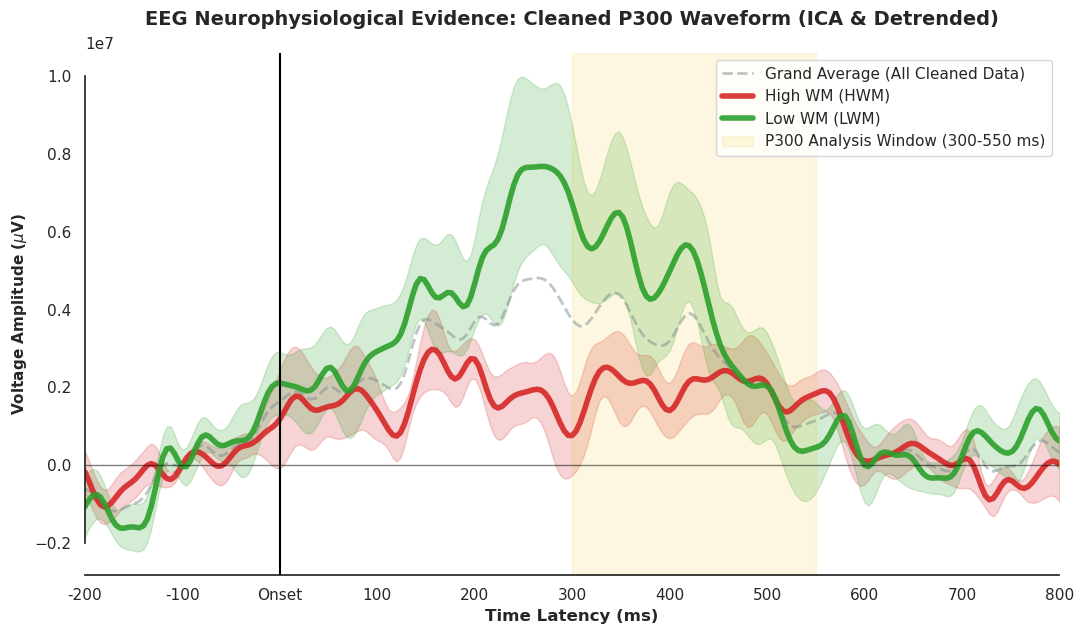

In [24]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']

all_erp_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = sorted(glob.glob(search_path))

if not file_list:
    raise FileNotFoundError(f"Error: No .vhdr files found in {data_dir}")

for file_path in file_list:
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        rename_dict = {}
        for ch in raw.ch_names:
            if ch.upper() == 'FP1': rename_dict[ch] = 'Fp1'
            elif ch.upper() == 'FP2': rename_dict[ch] = 'Fp2'
        if rename_dict:
            raw.rename_channels(rename_dict)
        
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        _data = raw._data
        if np.isnan(_data).any() or np.isinf(_data).any():
            raw._data = np.nan_to_num(_data, nan=0.0, posinf=0.0, neginf=0.0)
        
        eeg_ch_names = [ch for ch in raw.ch_names if mne.channel_type(raw.info, raw.ch_names.index(ch)) == 'eeg']
        eeg_data = raw.get_data(picks=eeg_ch_names)
        ch_stds = np.std(eeg_data, axis=1)
        median_std = np.median(ch_stds)
        
        detected_bads = []
        invalid_chs = []
        
        for idx, ch_name in enumerate(raw.ch_names):
            if ch_name in eeg_ch_names:
                ch_pos = raw.info['chs'][idx]['loc'][:3]
                eeg_idx = eeg_ch_names.index(ch_name)
                ch_data = eeg_data[eeg_idx]
                
                if np.isnan(ch_pos).any() or np.isinf(ch_pos).any() or np.all(ch_pos == 0):
                    invalid_chs.append(ch_name)
                    continue
                    
                if ch_stds[eeg_idx] > 10 * median_std or ch_stds[eeg_idx] == 0:
                    detected_bads.append(ch_name)
                elif np.max(np.abs(ch_data)) > 2000e-6:
                    detected_bads.append(ch_name)

        if invalid_chs:
            raw.drop_channels(invalid_chs)

        if len(detected_bads) < (len(eeg_ch_names) / 2):
            if detected_bads:
                raw.info['bads'] = list(set([ch for ch in raw.info['bads'] if ch in raw.ch_names] + detected_bads))
        
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=30.0, fir_design='firwin', verbose=False)
        
        n_components = min(15, len(mne.pick_types(raw_for_ica.info, eeg=True, exclude='bads')))
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, method='fastica', max_iter=800)
        ica.fit(raw_for_ica, verbose=False)
        
        ica.exclude = []
        eog_chs = [ch for ch in raw.ch_names if 'eog' in ch.lower()]
        if not eog_chs:
            eog_chs = [ch for ch in ['Fp1', 'Fp2'] if ch in raw.ch_names and ch not in raw.info['bads']]
            
        if eog_chs:
            try:
                eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica, ch_name=eog_chs[0], threshold=2.5, verbose=False)
                ica.exclude = eog_indices
            except ValueError:
                pass

        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        if ica.exclude:
            raw = ica.apply(raw, verbose=False)

        if len(raw.info['bads']) > 0:
            try:
                raw.interpolate_bads(reset_bads=True, verbose=False)
            except Exception:
                raw.info['bads'] = []

        events, event_id = mne.events_from_annotations(raw, verbose=False)
        
        if len(event_id) == 0 or events.size == 0:
            sub_dir = os.path.dirname(file_path)
            tsv_path = os.path.join(sub_dir, f"{sub_str}_task-nback_events.tsv")
            
            if os.path.exists(tsv_path):
                df_events = pd.read_csv(tsv_path, sep='\t')
                df_events = df_events[df_events['trial_type'].str.contains('back', na=False)]
                
                if not df_events.empty:
                    mne_events = []
                    sfreq = raw.info['sfreq']
                    for _, row in df_events.iterrows():
                        onset_sample = int(row['onset'] * sfreq)
                        mne_events.append([onset_sample, 0, 1])
                    
                    events = np.array(mne_events)
                    include_events = {'n-back_Trial': 1}
                else:
                    continue
            else:
                continue
        else:
            target_trigger_name = 'Stimulus/n-backMarkers'
            if target_trigger_name in event_id:
                include_events = {target_trigger_name: event_id[target_trigger_name]}
            else:
                stim_keys = [k for k in event_id.keys() if 'stimulus' in k.lower() or 'back' in k.lower()]
                if stim_keys:
                    include_events = {stim_keys[0]: event_id[stim_keys[0]]}
                else:
                    first_key = list(event_id.keys())[0]
                    include_events = {first_key: event_id[first_key]}

        epochs = mne.Epochs(
            raw, events, event_id=include_events, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, 
            detrend=1,                  
            reject=None,     
            reject_by_annotation=True,  
            verbose=False
        )

        if len(epochs) == 0:
            continue

        available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
        target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
        
        evoked = epochs.average(picks=[target_ch])
        if evoked.data.size == 0 or evoked.data.shape[0] == 0:
            continue
            
        evoked_data = evoked.data[0] * 1e6
        times = epochs.times
        
        for t_idx, t in enumerate(times):
            all_erp_records.append({
                'Subject': sub_str,
                'Group': group_label,
                'Time': t,
                'Amplitude': evoked_data[t_idx]
            })
            
    except Exception as e:
        print(f"Error processing {sub_str}: {e}")

df_real_erp = pd.DataFrame(all_erp_records)

if not df_real_erp.empty:
    fig, ax = plt.subplots(figsize=(11, 6.5))
    sns.set_theme(style="white")

    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', 
        color='#7f8c8d', linewidth=2, linestyle='--', label='Grand Average (All Cleaned Data)',
        errorbar=None, alpha=0.5, ax=ax
    )

    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', hue='Group',
        palette={'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'},
        linewidth=4, errorbar='se', alpha=0.9, ax=ax
    )

    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.12, label='P300 Analysis Window (300-550 ms)')

    plt.title("EEG Neurophysiological Evidence: Cleaned P300 Waveform (ICA & Detrended)", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
    plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
    plt.xlim(-0.2, 0.8)

    x_ticks = np.arange(-0.2, 0.9, 0.1)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else 'Onset' for x in x_ticks])
    
    plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
    sns.despine(trim=True)

    plt.tight_layout()
    plt.savefig('p300_cleaned_final_waveform.png', dpi=300, bbox_inches='tight')
    plt.show()

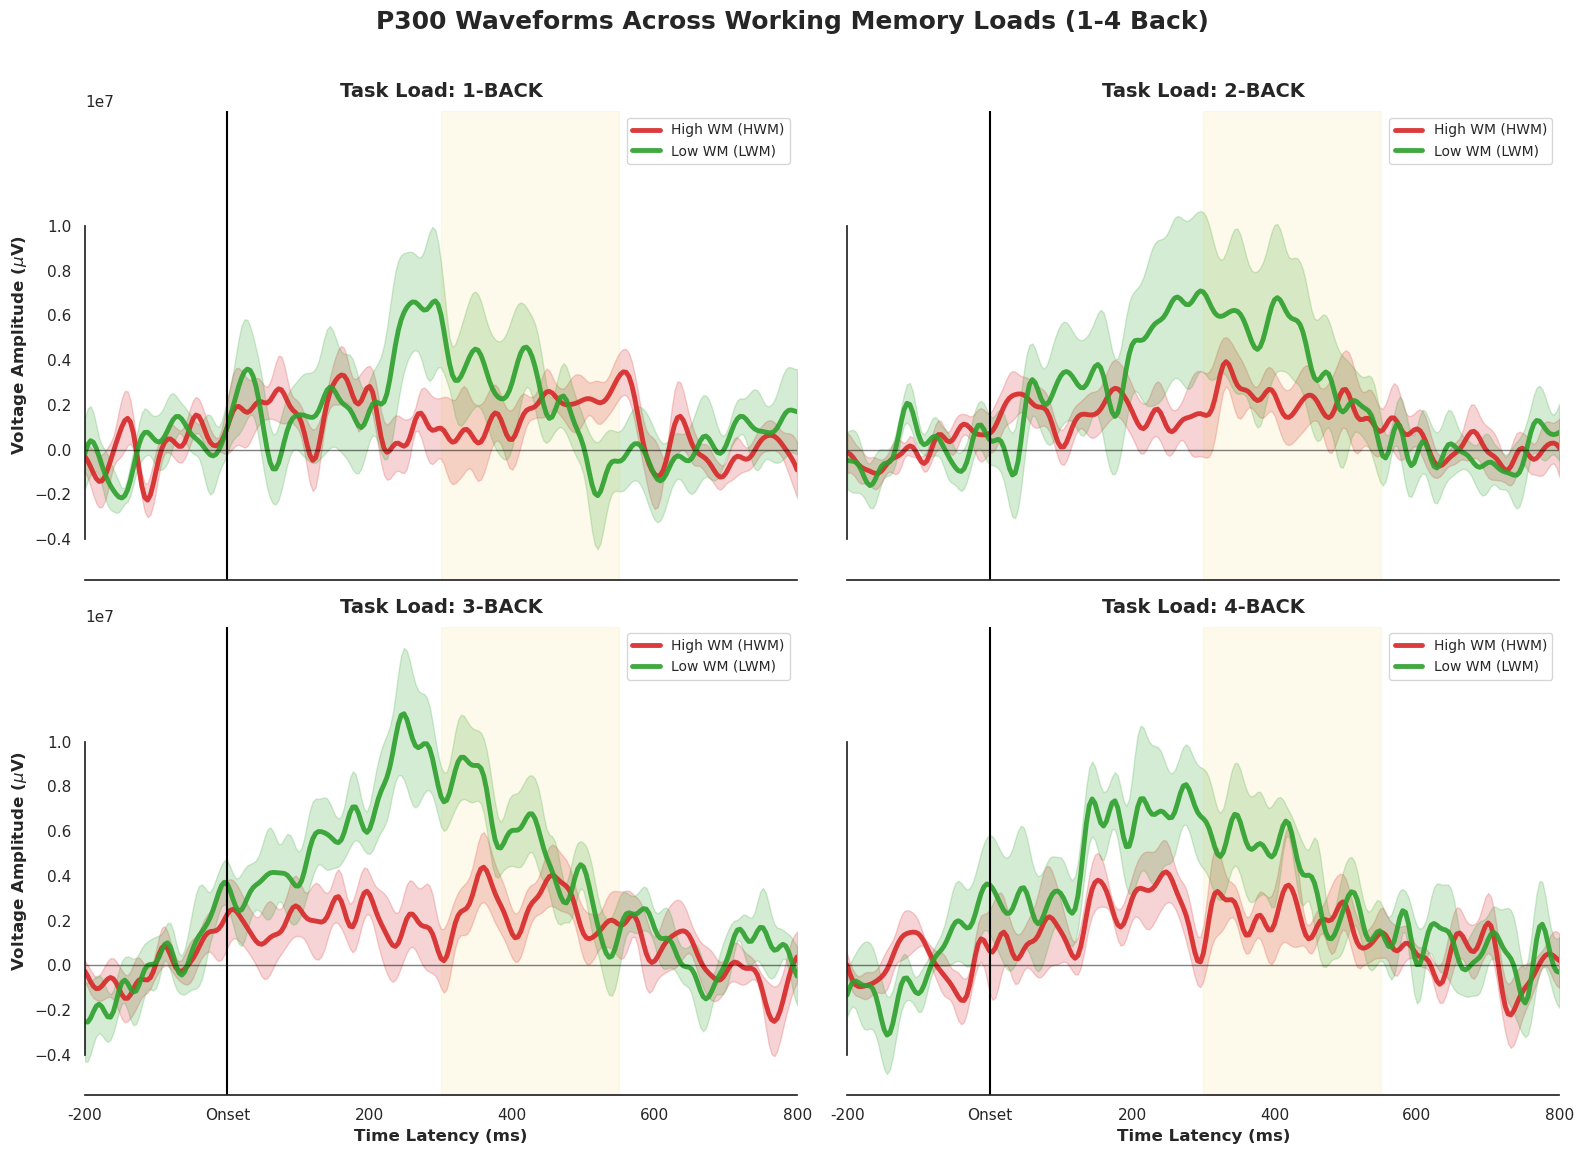

In [25]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']

all_erp_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = sorted(glob.glob(search_path))

if not file_list:
    raise FileNotFoundError(f"Error: No .vhdr files found in {data_dir}")

for file_path in file_list:
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        rename_dict = {}
        for ch in raw.ch_names:
            if ch.upper() == 'FP1': rename_dict[ch] = 'Fp1'
            elif ch.upper() == 'FP2': rename_dict[ch] = 'Fp2'
        if rename_dict:
            raw.rename_channels(rename_dict)
        
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        _data = raw._data
        if np.isnan(_data).any() or np.isinf(_data).any():
            raw._data = np.nan_to_num(_data, nan=0.0, posinf=0.0, neginf=0.0)
        
        eeg_ch_names = [ch for ch in raw.ch_names if mne.channel_type(raw.info, raw.ch_names.index(ch)) == 'eeg']
        eeg_data = raw.get_data(picks=eeg_ch_names)
        ch_stds = np.std(eeg_data, axis=1)
        median_std = np.median(ch_stds)
        
        detected_bads = []
        invalid_chs = []
        
        for idx, ch_name in enumerate(raw.ch_names):
            if ch_name in eeg_ch_names:
                ch_pos = raw.info['chs'][idx]['loc'][:3]
                eeg_idx = eeg_ch_names.index(ch_name)
                ch_data = eeg_data[eeg_idx]
                
                if np.isnan(ch_pos).any() or np.isinf(ch_pos).any() or np.all(ch_pos == 0):
                    invalid_chs.append(ch_name)
                    continue
                    
                if ch_stds[eeg_idx] > 10 * median_std or ch_stds[eeg_idx] == 0:
                    detected_bads.append(ch_name)
                elif np.max(np.abs(ch_data)) > 2000e-6:
                    detected_bads.append(ch_name)

        if invalid_chs:
            raw.drop_channels(invalid_chs)

        if len(detected_bads) < (len(eeg_ch_names) / 2):
            if detected_bads:
                raw.info['bads'] = list(set([ch for ch in raw.info['bads'] if ch in raw.ch_names] + detected_bads))
        
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=30.0, fir_design='firwin', verbose=False)
        n_components = min(15, len(mne.pick_types(raw_for_ica.info, eeg=True, exclude='bads')))
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, method='fastica', max_iter=800)
        ica.fit(raw_for_ica, verbose=False)
        
        ica.exclude = []
        eog_chs = [ch for ch in raw.ch_names if 'eog' in ch.lower()]
        if not eog_chs:
            eog_chs = [ch for ch in ['Fp1', 'Fp2'] if ch in raw.ch_names and ch not in raw.info['bads']]
            
        if eog_chs:
            try:
                eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica, ch_name=eog_chs[0], threshold=2.5, verbose=False)
                ica.exclude = eog_indices
            except ValueError:
                pass

        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        if ica.exclude:
            raw = ica.apply(raw, verbose=False)

        if len(raw.info['bads']) > 0:
            try:
                raw.interpolate_bads(reset_bads=True, verbose=False)
            except Exception:
                raw.info['bads'] = []

        sub_dir = os.path.dirname(file_path)
        tsv_path = os.path.join(sub_dir, f"{sub_str}_task-nback_events.tsv")
        
        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        
        for load in [1, 2, 3, 4]:
            load_str = f"{load}-back"
            df_load = df_events[df_events['trial_type'].str.contains(load_str, na=False)]
            
            if df_load.empty:
                continue
                
            mne_events = []
            sfreq = raw.info['sfreq']
            for _, row in df_load.iterrows():
                onset_sample = int(row['onset'] * sfreq)
                mne_events.append([onset_sample, 0, load])
                
            events = np.array(mne_events)
            include_events = {load_str: load}
            
            try:
                epochs = mne.Epochs(
                    raw, events, event_id=include_events, 
                    tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
                    preload=True, detrend=1, reject=None, 
                    reject_by_annotation=True, verbose=False
                )

                if len(epochs) == 0:
                    continue

                available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
                target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
                
                evoked = epochs.average(picks=[target_ch])
                if evoked.data.size == 0 or evoked.data.shape[0] == 0:
                    continue
                    
                evoked_data = evoked.data[0] * 1e6
                times = epochs.times
                
                for t_idx, t in enumerate(times):
                    all_erp_records.append({
                        'Subject': sub_str,
                        'Group': group_label,
                        'Load': load_str,
                        'Time': t,
                        'Amplitude': evoked_data[t_idx]
                    })
            except Exception:
                pass
                
    except Exception as e:
        print(f"Error processing {sub_str}: {e}")

df_real_erp = pd.DataFrame(all_erp_records)

if not df_real_erp.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
    axes = axes.flatten()
    sns.set_theme(style="white")

    loads = ['1-back', '2-back', '3-back', '4-back']
    colors = {'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'}

    for idx, load_name in enumerate(loads):
        ax = axes[idx]
        df_sub = df_real_erp[df_real_erp['Load'] == load_name]
        
        if df_sub.empty:
            ax.text(0.5, 0.5, f"No Data for {load_name}", ha='center', va='center')
            continue
            
        sns.lineplot(
            data=df_sub, x='Time', y='Amplitude', hue='Group',
            palette=colors, linewidth=3.5, errorbar='se', alpha=0.9, ax=ax
        )
        
        ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
        ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
        ax.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.08)
        
        ax.set_title(f"Task Load: {load_name.upper()}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlim(-0.2, 0.8)
        
        if idx >= 2:
            ax.set_xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
            x_ticks = np.arange(-0.2, 0.9, 0.2)
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([f"{int(x*1000)}" if x != 0 else 'Onset' for x in x_ticks])
        else:
            ax.set_xlabel("")
            
        if idx % 2 == 0:
            ax.set_ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.legend(loc="upper right", frameon=True, facecolor='white', fontsize=10)
        sns.despine(ax=ax, trim=True)

    plt.suptitle("P300 Waveforms Across Working Memory Loads (1-4 Back)", fontsize=18, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('p300_loads_1to4_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

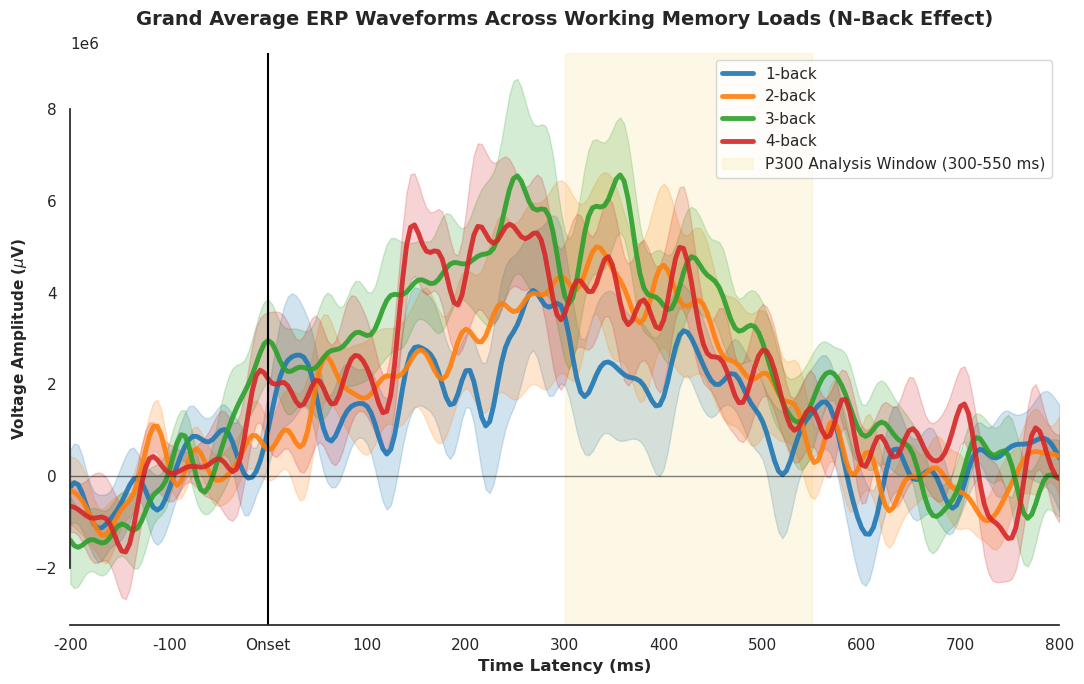

In [26]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']
all_allowed_subs = hwm_subs + lwm_subs

all_erp_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = sorted(glob.glob(search_path))

if not file_list:
    raise FileNotFoundError(f"Error: No .vhdr files found in {data_dir}")

for file_path in file_list:
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str not in all_allowed_subs:
        continue  
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        rename_dict = {}
        for ch in raw.ch_names:
            if ch.upper() == 'FP1': rename_dict[ch] = 'Fp1'
            elif ch.upper() == 'FP2': rename_dict[ch] = 'Fp2'
        if rename_dict:
            raw.rename_channels(rename_dict)
        
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        _data = raw._data
        if np.isnan(_data).any() or np.isinf(_data).any():
            raw._data = np.nan_to_num(_data, nan=0.0, posinf=0.0, neginf=0.0)
        
        eeg_ch_names = [ch for ch in raw.ch_names if mne.channel_type(raw.info, raw.ch_names.index(ch)) == 'eeg']
        eeg_data = raw.get_data(picks=eeg_ch_names)
        ch_stds = np.std(eeg_data, axis=1)
        median_std = np.median(ch_stds)
        
        detected_bads = []
        invalid_chs = []
        
        for idx, ch_name in enumerate(raw.ch_names):
            if ch_name in eeg_ch_names:
                ch_pos = raw.info['chs'][idx]['loc'][:3]
                eeg_idx = eeg_ch_names.index(ch_name)
                ch_data = eeg_data[eeg_idx]
                
                if np.isnan(ch_pos).any() or np.isinf(ch_pos).any() or np.all(ch_pos == 0):
                    invalid_chs.append(ch_name)
                    continue
                    
                if ch_stds[eeg_idx] > 10 * median_std or ch_stds[eeg_idx] == 0:
                    detected_bads.append(ch_name)
                elif np.max(np.abs(ch_data)) > 2000e-6:
                    detected_bads.append(ch_name)

        if invalid_chs:
            raw.drop_channels(invalid_chs)

        if len(detected_bads) < (len(eeg_ch_names) / 2):
            if detected_bads:
                raw.info['bads'] = list(set([ch for ch in raw.info['bads'] if ch in raw.ch_names] + detected_bads))
        
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=30.0, fir_design='firwin', verbose=False)
        n_components = min(15, len(mne.pick_types(raw_for_ica.info, eeg=True, exclude='bads')))
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, method='fastica', max_iter=800)
        ica.fit(raw_for_ica, verbose=False)
        
        ica.exclude = []
        eog_chs = [ch for ch in raw.ch_names if 'eog' in ch.lower()]
        if not eog_chs:
            eog_chs = [ch for ch in ['Fp1', 'Fp2'] if ch in raw.ch_names and ch not in raw.info['bads']]
            
        if eog_chs:
            try:
                eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica, ch_name=eog_chs[0], threshold=2.5, verbose=False)
                ica.exclude = eog_indices
            except ValueError:
                pass

        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        if ica.exclude:
            raw = ica.apply(raw, verbose=False)

        if len(raw.info['bads']) > 0:
            try:
                raw.interpolate_bads(reset_bads=True, verbose=False)
            except Exception:
                raw.info['bads'] = []

        sub_dir = os.path.dirname(file_path)
        tsv_path = os.path.join(sub_dir, f"{sub_str}_task-nback_events.tsv")
        
        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        
        for load in [1, 2, 3, 4]:
            load_str = f"{load}-back"
            df_load = df_events[df_events['trial_type'].str.contains(load_str, na=False)]
            
            if df_load.empty:
                continue
                
            mne_events = []
            sfreq = raw.info['sfreq']
            for _, row in df_load.iterrows():
                onset_sample = int(row['onset'] * sfreq)
                mne_events.append([onset_sample, 0, load])
                
            events = np.array(mne_events)
            include_events = {load_str: load}
            
            try:
                epochs = mne.Epochs(
                    raw, events, event_id=include_events, 
                    tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
                    preload=True, detrend=1, reject=None, 
                    reject_by_annotation=True, verbose=False
                )

                if len(epochs) == 0:
                    continue

                available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
                target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
                
                evoked = epochs.average(picks=[target_ch])
                if evoked.data.size == 0 or evoked.data.shape[0] == 0:
                    continue
                    
                evoked_data = evoked.data[0] * 1e6
                times = epochs.times
                
                for t_idx, t in enumerate(times):
                    all_erp_records.append({
                        'Subject': sub_str,
                        'Load': load_str,
                        'Time': t,
                        'Amplitude': evoked_data[t_idx]
                    })
            except Exception:
                pass
                
    except Exception as e:
        print(f"Error processing {sub_str}: {e}")

df_real_erp = pd.DataFrame(all_erp_records)

if not df_real_erp.empty:
    fig, ax = plt.subplots(figsize=(11, 7))
    sns.set_theme(style="white")

    load_palette = {
        '1-back': '#1f77b4',  
        '2-back': '#ff7f0e',  
        '3-back': '#2ca02c',  
        '4-back': '#d62728'   
    }

    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', hue='Load',
        palette=load_palette, linewidth=3.5, errorbar='se', alpha=0.9, ax=ax
    )

    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.1, label='P300 Analysis Window (300-550 ms)')

    plt.title("Grand Average ERP Waveforms Across Working Memory Loads (N-Back Effect)", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
    plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
    plt.xlim(-0.2, 0.8)

    x_ticks = np.arange(-0.2, 0.9, 0.1)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else 'Onset' for x in x_ticks])
    
    plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
    sns.despine(trim=True)

    plt.tight_layout()
    plt.savefig('p300_grand_average_1to4back.png', dpi=300, bbox_inches='tight')
    plt.show()

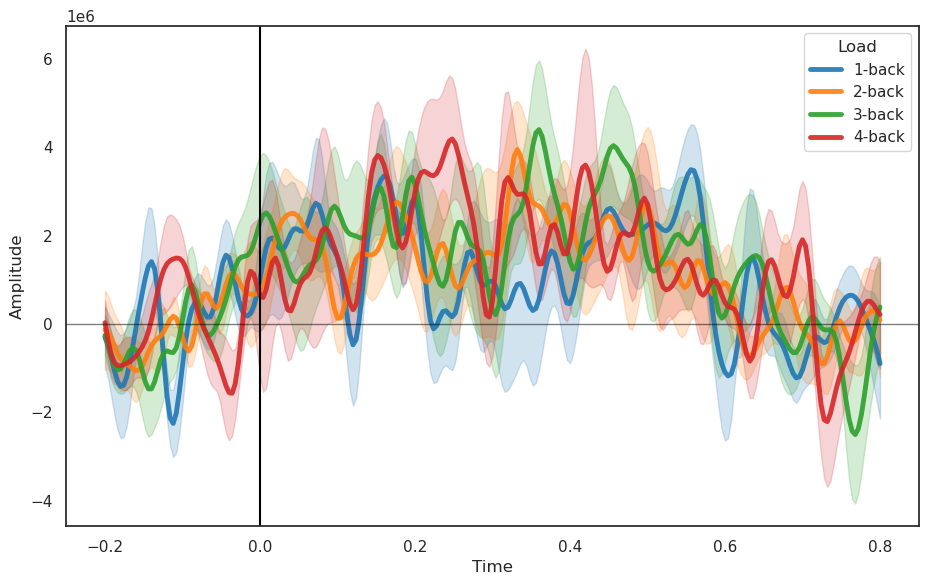

In [27]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']

all_erp_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = sorted(glob.glob(search_path))

if not file_list:
    raise FileNotFoundError(f"Error: No .vhdr files found in {data_dir}")

for file_path in file_list:
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        rename_dict = {}
        for ch in raw.ch_names:
            if ch.upper() == 'FP1': rename_dict[ch] = 'Fp1'
            elif ch.upper() == 'FP2': rename_dict[ch] = 'Fp2'
        if rename_dict:
            raw.rename_channels(rename_dict)
        
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        _data = raw._data
        if np.isnan(_data).any() or np.isinf(_data).any():
            raw._data = np.nan_to_num(_data, nan=0.0, posinf=0.0, neginf=0.0)
        
        eeg_ch_names = [ch for ch in raw.ch_names if mne.channel_type(raw.info, raw.ch_names.index(ch)) == 'eeg']
        eeg_data = raw.get_data(picks=eeg_ch_names)
        ch_stds = np.std(eeg_data, axis=1)
        median_std = np.median(ch_stds)
        
        detected_bads = []
        invalid_chs = []
        
        for idx, ch_name in enumerate(raw.ch_names):
            if ch_name in eeg_ch_names:
                ch_pos = raw.info['chs'][idx]['loc'][:3]
                eeg_idx = eeg_ch_names.index(ch_name)
                ch_data = eeg_data[eeg_idx]
                
                if np.isnan(ch_pos).any() or np.isinf(ch_pos).any() or np.all(ch_pos == 0):
                    invalid_chs.append(ch_name)
                    continue
                    
                if ch_stds[eeg_idx] > 10 * median_std or ch_stds[eeg_idx] == 0:
                    detected_bads.append(ch_name)
                elif np.max(np.abs(ch_data)) > 2000e-6:
                    detected_bads.append(ch_name)

        if invalid_chs:
            raw.drop_channels(invalid_chs)

        if len(detected_bads) < (len(eeg_ch_names) / 2):
            if detected_bads:
                raw.info['bads'] = list(set([ch for ch in raw.info['bads'] if ch in raw.ch_names] + detected_bads))
        
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=30.0, fir_design='firwin', verbose=False)
        n_components = min(15, len(mne.pick_types(raw_for_ica.info, eeg=True, exclude='bads')))
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, method='fastica', max_iter=800)
        ica.fit(raw_for_ica, verbose=False)
        
        ica.exclude = []
        eog_chs = [ch for ch in raw.ch_names if 'eog' in ch.lower()]
        if not eog_chs:
            eog_chs = [ch for ch in ['Fp1', 'Fp2'] if ch in raw.ch_names and ch not in raw.info['bads']]
            
        if eog_chs:
            try:
                eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica, ch_name=eog_chs[0], threshold=2.5, verbose=False)
                ica.exclude = eog_indices
            except ValueError:
                pass

        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        if ica.exclude:
            raw = ica.apply(raw, verbose=False)

        if len(raw.info['bads']) > 0:
            try:
                raw.interpolate_bads(reset_bads=True, verbose=False)
            except Exception:
                raw.info['bads'] = []

        sub_dir = os.path.dirname(file_path)
        tsv_path = os.path.join(sub_dir, f"{sub_str}_task-nback_events.tsv")
        
        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        
        for load in [1, 2, 3, 4]:
            load_str = f"{load}-back"
            df_load = df_events[df_events['trial_type'].str.contains(load_str, na=False)]
            
            if df_load.empty:
                continue
                
            mne_events = []
            sfreq = raw.info['sfreq']
            for _, row in df_load.iterrows():
                onset_sample = int(row['onset'] * sfreq)
                mne_events.append([onset_sample, 0, load])
                
            events = np.array(mne_events)
            include_events = {load_str: load}
            
            try:
                epochs = mne.Epochs(
                    raw, events, event_id=include_events, 
                    tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
                    preload=True, detrend=1, reject=None, 
                    reject_by_annotation=True, verbose=False
                )

                if len(epochs) == 0:
                    continue

                available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
                target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
                
                evoked = epochs.average(picks=[target_ch])
                if evoked.data.size == 0 or evoked.data.shape[0] == 0:
                    continue
                    
                evoked_data = evoked.data[0] * 1e6
                times = epochs.times
                
                for t_idx, t in enumerate(times):
                    all_erp_records.append({
                        'Subject': sub_str,
                        'Group': group_label,
                        'Load': load_str,
                        'Time': t,
                        'Amplitude': evoked_data[t_idx]
                    })
            except Exception:
                pass
                
    except Exception as e:
        print(f"Error processing {sub_str}: {e}")

df_real_erp = pd.DataFrame(all_erp_records)

# 定義統一的難度顏色調色盤
load_palette = {
    '1-back': '#1f77b4',  # 藍
    '2-back': '#ff7f0e',  # 橘
    '3-back': '#2ca02c',  # 綠
    '4-back': '#d62728'   # 紅
}

if not df_real_erp.empty:
    sns.set_theme(style="white")
    
   
    df_hwm = df_real_erp[df_real_erp['Group'] == 'High WM (HWM)']
    if not df_hwm.empty:
        fig, ax = plt.subplots(figsize=(11, 6.5))
        sns.lineplot(
            data=df_hwm, x='Time', y='Amplitude', hue='Load',
            palette=load_palette, linewidth=3.5, errorbar='se', alpha=0.9, ax=ax
        )
        plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
        plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)

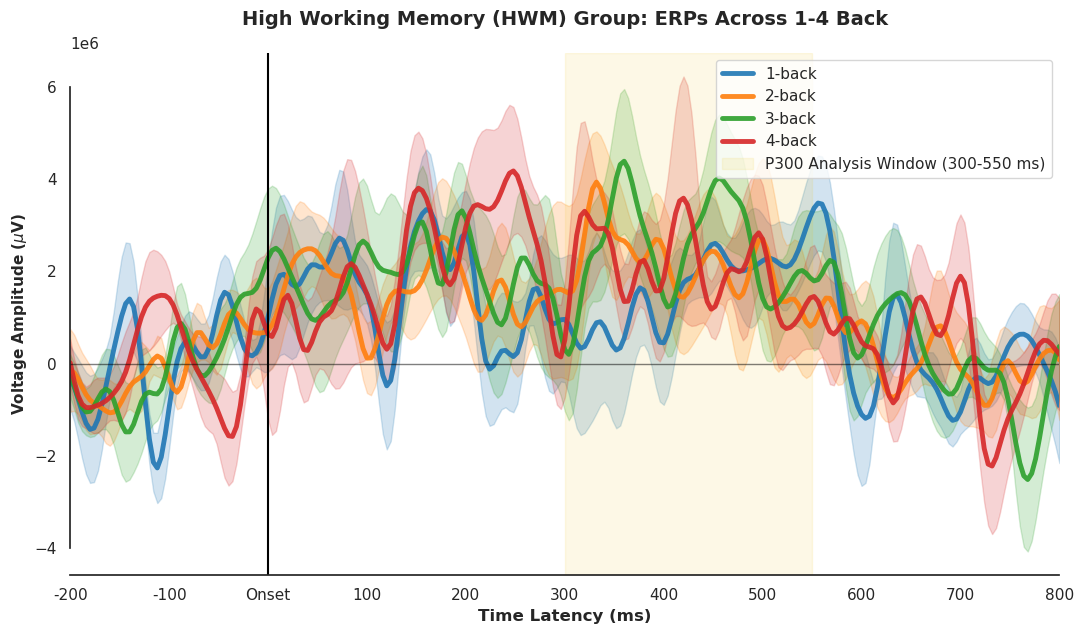

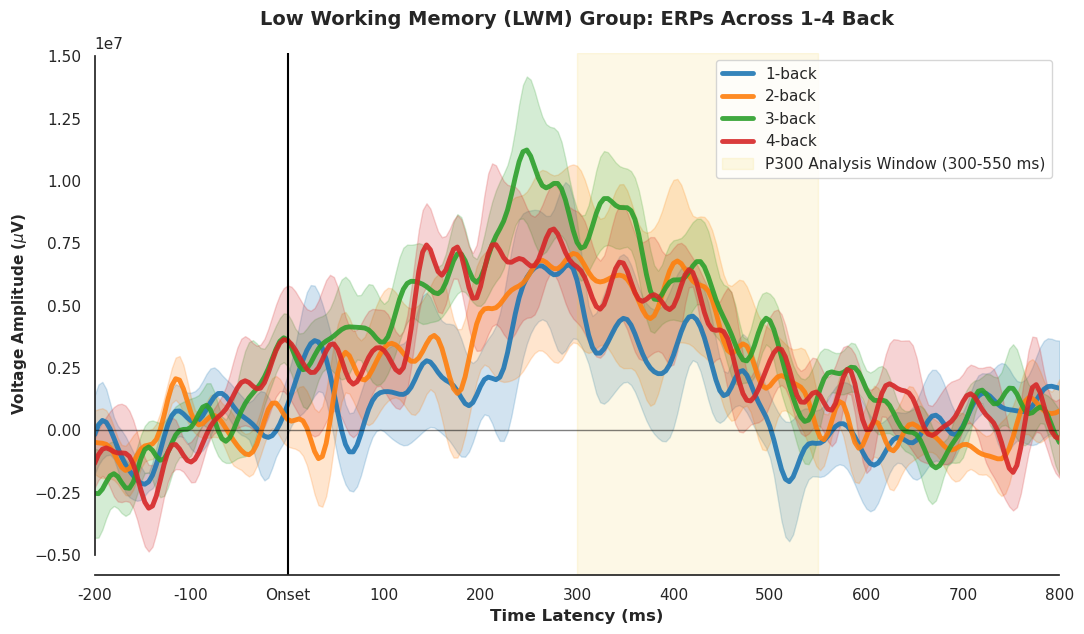

In [28]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']

all_erp_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = sorted(glob.glob(search_path))

if not file_list:
    raise FileNotFoundError(f"Error: No .vhdr files found in {data_dir}")

for file_path in file_list:
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        rename_dict = {}
        for ch in raw.ch_names:
            if ch.upper() == 'FP1': rename_dict[ch] = 'Fp1'
            elif ch.upper() == 'FP2': rename_dict[ch] = 'Fp2'
        if rename_dict:
            raw.rename_channels(rename_dict)
        
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        _data = raw._data
        if np.isnan(_data).any() or np.isinf(_data).any():
            raw._data = np.nan_to_num(_data, nan=0.0, posinf=0.0, neginf=0.0)
        
        eeg_ch_names = [ch for ch in raw.ch_names if mne.channel_type(raw.info, raw.ch_names.index(ch)) == 'eeg']
        eeg_data = raw.get_data(picks=eeg_ch_names)
        ch_stds = np.std(eeg_data, axis=1)
        median_std = np.median(ch_stds)
        
        detected_bads = []
        invalid_chs = []
        
        for idx, ch_name in enumerate(raw.ch_names):
            if ch_name in eeg_ch_names:
                ch_pos = raw.info['chs'][idx]['loc'][:3]
                eeg_idx = eeg_ch_names.index(ch_name)
                ch_data = eeg_data[eeg_idx]
                
                if np.isnan(ch_pos).any() or np.isinf(ch_pos).any() or np.all(ch_pos == 0):
                    invalid_chs.append(ch_name)
                    continue
                    
                if ch_stds[eeg_idx] > 10 * median_std or ch_stds[eeg_idx] == 0:
                    detected_bads.append(ch_name)
                elif np.max(np.abs(ch_data)) > 2000e-6:
                    detected_bads.append(ch_name)

        if invalid_chs:
            raw.drop_channels(invalid_chs)

        if len(detected_bads) < (len(eeg_ch_names) / 2):
            if detected_bads:
                raw.info['bads'] = list(set([ch for ch in raw.info['bads'] if ch in raw.ch_names] + detected_bads))
        
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=30.0, fir_design='firwin', verbose=False)
        n_components = min(15, len(mne.pick_types(raw_for_ica.info, eeg=True, exclude='bads')))
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, method='fastica', max_iter=800)
        ica.fit(raw_for_ica, verbose=False)
        
        ica.exclude = []
        eog_chs = [ch for ch in raw.ch_names if 'eog' in ch.lower()]
        if not eog_chs:
            eog_chs = [ch for ch in ['Fp1', 'Fp2'] if ch in raw.ch_names and ch not in raw.info['bads']]
            
        if eog_chs:
            try:
                eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica, ch_name=eog_chs[0], threshold=2.5, verbose=False)
                ica.exclude = eog_indices
            except ValueError:
                pass

        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        if ica.exclude:
            raw = ica.apply(raw, verbose=False)

        if len(raw.info['bads']) > 0:
            try:
                raw.interpolate_bads(reset_bads=True, verbose=False)
            except Exception:
                raw.info['bads'] = []

        sub_dir = os.path.dirname(file_path)
        tsv_path = os.path.join(sub_dir, f"{sub_str}_task-nback_events.tsv")
        
        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        
        for load in [1, 2, 3, 4]:
            load_str = f"{load}-back"
            df_load = df_events[df_events['trial_type'].str.contains(load_str, na=False)]
            
            if df_load.empty:
                continue
                
            mne_events = []
            sfreq = raw.info['sfreq']
            for _, row in df_load.iterrows():
                onset_sample = int(row['onset'] * sfreq)
                mne_events.append([onset_sample, 0, load])
                
            events = np.array(mne_events)
            include_events = {load_str: load}
            
            try:
                epochs = mne.Epochs(
                    raw, events, event_id=include_events, 
                    tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
                    preload=True, detrend=1, reject=None, 
                    reject_by_annotation=True, verbose=False
                )

                if len(epochs) == 0:
                    continue

                available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
                target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
                
                evoked = epochs.average(picks=[target_ch])
                if evoked.data.size == 0 or evoked.data.shape[0] == 0:
                    continue
                    
                evoked_data = evoked.data[0] * 1e6
                times = epochs.times
                
                for t_idx, t in enumerate(times):
                    all_erp_records.append({
                        'Subject': sub_str,
                        'Group': group_label,
                        'Load': load_str,
                        'Time': t,
                        'Amplitude': evoked_data[t_idx]
                    })
            except Exception:
                pass
                
    except Exception as e:
        print(f"Error processing {sub_str}: {e}")

df_real_erp = pd.DataFrame(all_erp_records)


load_palette = {
    '1-back': '#1f77b4',  
    '2-back': '#ff7f0e', 
    '3-back': '#2ca02c',  
    '4-back': '#d62728'   
}

if not df_real_erp.empty:
    sns.set_theme(style="white")
    
   
    df_hwm = df_real_erp[df_real_erp['Group'] == 'High WM (HWM)']
    if not df_hwm.empty:
        fig, ax = plt.subplots(figsize=(11, 6.5))
        sns.lineplot(
            data=df_hwm, x='Time', y='Amplitude', hue='Load',
            palette=load_palette, linewidth=3.5, errorbar='se', alpha=0.9, ax=ax
        )
        plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
        plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
        plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.1, label='P300 Analysis Window (300-550 ms)')
        
        plt.title("High Working Memory (HWM) Group: ERPs Across 1-4 Back", fontsize=14, fontweight='bold', pad=20)
        plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
        plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
        plt.xlim(-0.2, 0.8)
        x_ticks = np.arange(-0.2, 0.9, 0.1)
        plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else 'Onset' for x in x_ticks])
        plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
        sns.despine(trim=True)
        plt.tight_layout()
        plt.savefig('p300_hwm_1to4back.png', dpi=300, bbox_inches='tight')
        plt.show()

   
    df_lwm = df_real_erp[df_real_erp['Group'] == 'Low WM (LWM)']
    if not df_lwm.empty:
        fig, ax = plt.subplots(figsize=(11, 6.5))
        sns.lineplot(
            data=df_lwm, x='Time', y='Amplitude', hue='Load',
            palette=load_palette, linewidth=3.5, errorbar='se', alpha=0.9, ax=ax
        )
        plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
        plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
        plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.1, label='P300 Analysis Window (300-550 ms)')
        
        plt.title("Low Working Memory (LWM) Group: ERPs Across 1-4 Back", fontsize=14, fontweight='bold', pad=20)
        plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
        plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
        plt.xlim(-0.2, 0.8)
        plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else 'Onset' for x in x_ticks])
        plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
        sns.despine(trim=True)
        plt.tight_layout()
        plt.savefig('p300_lwm_1to4back.png', dpi=300, bbox_inches='tight')
        plt.show()

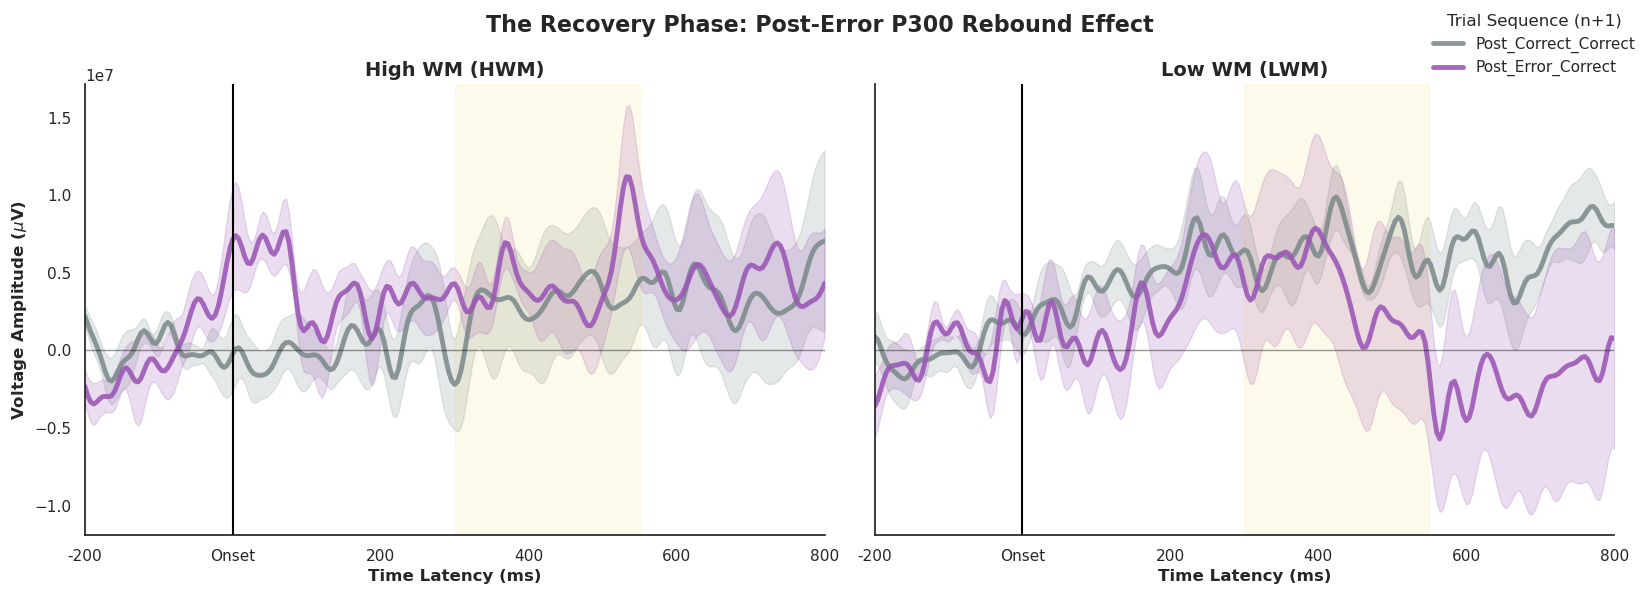

In [29]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-001', 'sub-002', 'sub-006', 'sub-008', 'sub-012', 'sub-020']
lwm_subs = ['sub-003', 'sub-005', 'sub-009', 'sub-010', 'sub-011', 'sub-018']

all_recovery_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        raw.set_eeg_reference(ref_channels=[], verbose=False)
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        
        base_no_ext = os.path.splitext(file_path)[0]
        tsv_path = base_no_ext.replace('_eeg', '_events') + '.tsv'
        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        df_events['prev_outcome'] = df_events['outcome'].shift(1)
        df_task = df_events[df_events['trial_type'].isin(['1-back', '2-back', '3-back', '4-back'])].copy()
        
        target_events_list = []
        sfreq = raw.info['sfreq']
        
        for _, row in df_task.iterrows():
            current_out = str(row['outcome']).strip().lower()
            prev_out = str(row['prev_outcome']).strip().lower()
            
            if 'correct' in current_out:
                onset_sec = float(row['onset'])
                sample_idx = int(np.round(onset_sec * sfreq))
                
                if 'wrong' in prev_out:
                    target_events_list.append([sample_idx, 0, 102])
                elif 'correct' in prev_out:
                    target_events_list.append([sample_idx, 0, 101])

        if not target_events_list:
            continue
            
        events = np.array(target_events_list)
        events = events[events[:, 0].argsort()]
        
        event_dict = {'Post_Correct_Correct': 101, 'Post_Error_Correct': 102}
        unique_codes = np.unique(events[:, 2])
        current_event_dict = {k: v for k, v in event_dict.items() if v in unique_codes}
        
        epochs = mne.Epochs(
            raw, events, event_id=current_event_dict, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
        target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
        
        for condition_name, condition_code in current_event_dict.items():
            evoked = epochs[condition_name].average(picks=target_ch)
            evoked_data = evoked.data[0] * 1e6
            times = evoked.times
            
            for t_idx, t in enumerate(times):
                all_recovery_records.append({
                    'Subject': sub_str,
                    'Group': group_label,
                    'Condition': condition_name,
                    'Time': t,
                    'Amplitude': evoked_data[t_idx]
                })
                
    except Exception:
        pass

df_recovery = pd.DataFrame(all_recovery_records)

if not df_recovery.empty:
    g = sns.FacetGrid(
        df_recovery, col="Group", hue="Condition", 
        palette={'Post_Correct_Correct': '#7f8c8d', 'Post_Error_Correct': '#9b59b6'}, 
        height=6, aspect=1.2, col_order=['High WM (HWM)', 'Low WM (LWM)']
    )
    
    g.map(sns.lineplot, "Time", "Amplitude", linewidth=3.5, errorbar='se', alpha=0.9)
    
    for ax in g.axes.flat:
        ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
        ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.4)
        ax.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.08, label='P300 Rebound Window')
        ax.set_xlim(-0.2, 0.8)
        
        x_ticks = np.arange(-0.2, 0.9, 0.2)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
        ax.set_xlabel("Time Latency (ms)", fontweight='bold')

    g.axes[0, 0].set_ylabel(r"Voltage Amplitude ($\mu$V)", fontweight='bold')
    g.set_titles(template="{col_name}", weight='bold', size=14)
    g.add_legend(title="Trial Sequence (n+1)", loc="upper right")
    
    plt.subplots_adjust(top=0.82)
    g.fig.suptitle("The Recovery Phase: Post-Error P300 Rebound Effect", fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('p300_error_recovery_perfect.png', dpi=300)
    plt.show()

In [30]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-001', 'sub-002', 'sub-006', 'sub-008', 'sub-012', 'sub-020']
lwm_subs = ['sub-003', 'sub-005', 'sub-009', 'sub-010', 'sub-011', 'sub-018']

all_recovery_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        raw.set_eeg_reference(ref_channels=[], verbose=False)
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        
        base_no_ext = os.path.splitext(file_path)[0]
        tsv_path = base_no_ext.replace('_eeg', '_events') + '.tsv'
        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        df_events['prev_outcome'] = df_events['outcome'].shift(1)
        df_task = df_events[df_events['trial_type'].isin(['1-back', '2-back', '3-back', '4-back'])].copy()
        
        target_events_list = []
        sfreq = raw.info['sfreq']
        
        for _, row in df_task.iterrows():
            current_out = str(row['outcome']).strip().lower()
            prev_out = str(row['prev_outcome']).strip().lower()
            
            if 'wrong' in prev_out:
                onset_sec = float(row['onset'])
                sample_idx = int(np.round(onset_sec * sfreq))
                
                if 'correct' in current_out:
                    target_events_list.append([sample_idx, 0, 201])
                elif 'wrong' in current_out:
                    target_events_list.append([sample_idx, 0, 202])

        if not target_events_list:
            continue
            
        events = np.array(target_events_list)
        events = events[events[:, 0].argsort()]
        
        event_dict = {'Post_Error_Correct': 201, 'Post_Error_Wrong': 202}
        unique_codes = np.unique(events[:, 2])
        current_event_dict = {k: v for k, v in event_dict.items() if v in unique_codes}
        
        if len(current_event_dict) < 2:
            continue
            
        epochs = mne.Epochs(
            raw, events, event_id=current_event_dict, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
        target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
        
        for condition_name, condition_code in current_event_dict.items():
            evoked = epochs[condition_name].average(picks=target_ch)
            evoked_data = evoked.data[0] * 1e6
            times = evoked.times
            
            for t_idx, t in enumerate(times):
                all_recovery_records.append({
                    'Subject': sub_str,
                    'Group': group_label,
                    'Condition': condition_name,
                    'Time': t,
                    'Amplitude': evoked_data[t_idx]
                })
                
    except Exception:
        pass

df_recovery = pd.DataFrame(all_recovery_records)

if not df_recovery.empty:
    df_recovery['Combined_Condition'] = df_recovery['Group'] + " - " + df_recovery['Condition']
    
    custom_palette = {
        'High WM (HWM) - Post_Error_Correct': '#1f77b4',
        'High WM (HWM) - Post_Error_Wrong': '#9467bd',
        'Low WM (LWM) - Post_Error_Correct': '#d62728',
        'Low WM (LWM) - Post_Error_Wrong': '#2ca02c'
    }
    
    label_mapping = {
        'High WM (HWM) - Post_Error_Correct': 'HWM: Post-Error Correct (Blue) -> Recovery',
        'High WM (HWM) - Post_Error_Wrong': 'HWM: Post-Error Wrong (Purple) -> Giving up',
        'Low WM (LWM) - Post_Error_Correct': 'LWM: Post-Error Correct (Red)',
        'Low WM (LWM) - Post_Error_Wrong': 'LWM: Post-Error Wrong (Green)'
    }
    df_recovery['Display_Label'] = df_recovery['Combined_Condition'].map(label_mapping)
    final_palette = {label_mapping[k]: v for k, v in custom_palette.items()}

    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid", context="talk")
    
    sns.lineplot(
        data=df_recovery, 
        x="Time", 
        y="Amplitude", 
        hue="Display_Label", 
        palette=final_palette,
        linewidth=3.5, 
        errorbar='se', 
        alpha=0.9
    )
    
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.4)
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.06, label='P300 Window')
    
    plt.xlim(-0.2, 0.8)
    x_ticks = np.arange(-0.2,

_IncompleteInputError: incomplete input (2537199559.py, line 140)

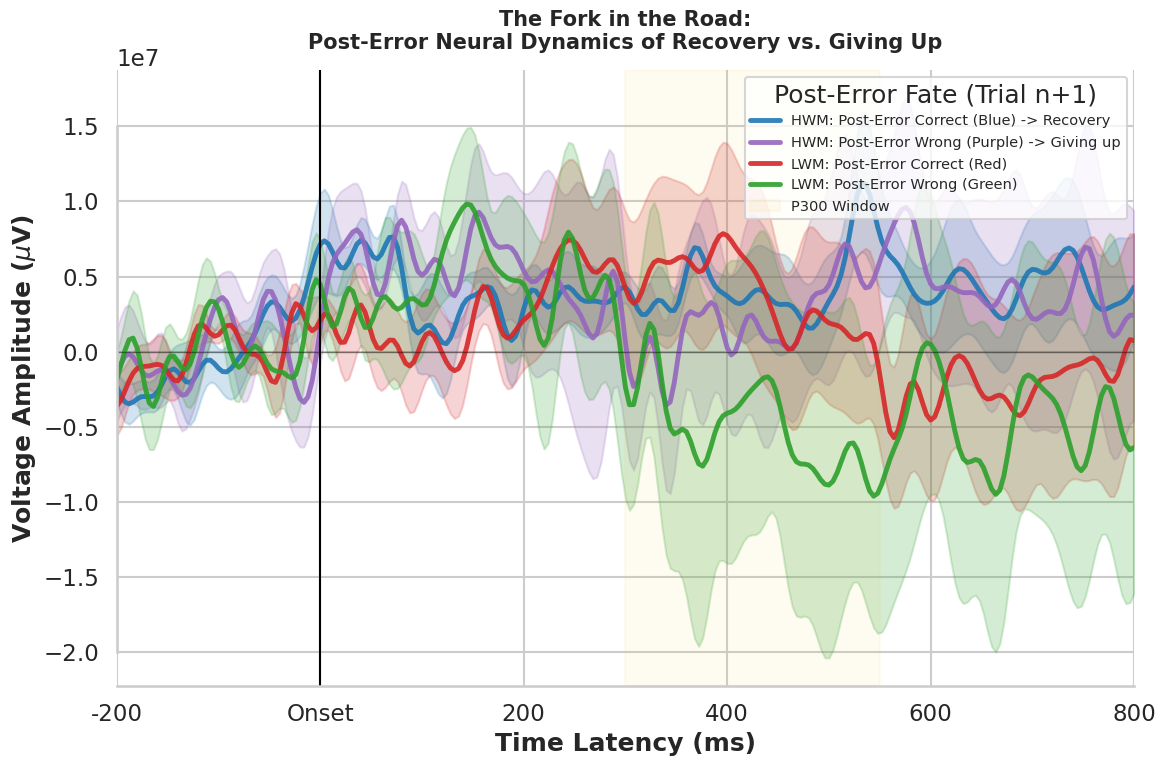

In [31]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-001', 'sub-002', 'sub-006', 'sub-008', 'sub-012', 'sub-020']
lwm_subs = ['sub-003', 'sub-005', 'sub-009', 'sub-010', 'sub-011', 'sub-018']

all_recovery_records = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue
        
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        raw.set_eeg_reference(ref_channels=[], verbose=False)
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        
        base_no_ext = os.path.splitext(file_path)[0]
        tsv_path = base_no_ext.replace('_eeg', '_events') + '.tsv'
        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        df_events['prev_outcome'] = df_events['outcome'].shift(1)
        df_task = df_events[df_events['trial_type'].isin(['1-back', '2-back', '3-back', '4-back'])].copy()
        
        target_events_list = []
        sfreq = raw.info['sfreq']
        
        for _, row in df_task.iterrows():
            current_out = str(row['outcome']).strip().lower()
            prev_out = str(row['prev_outcome']).strip().lower()
            
            if 'wrong' in prev_out:
                onset_sec = float(row['onset'])
                sample_idx = int(np.round(onset_sec * sfreq))
                
                if 'correct' in current_out:
                    target_events_list.append([sample_idx, 0, 201])
                elif 'wrong' in current_out:
                    target_events_list.append([sample_idx, 0, 202])

        if not target_events_list:
            continue
            
        events = np.array(target_events_list)
        events = events[events[:, 0].argsort()]
        
        event_dict = {'Post_Error_Correct': 201, 'Post_Error_Wrong': 202}
        unique_codes = np.unique(events[:, 2])
        current_event_dict = {k: v for k, v in event_dict.items() if v in unique_codes}
        
        if len(current_event_dict) < 2:
            continue
            
        epochs = mne.Epochs(
            raw, events, event_id=current_event_dict, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
        target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
        
        for condition_name, condition_code in current_event_dict.items():
            evoked = epochs[condition_name].average(picks=target_ch)
            evoked_data = evoked.data[0] * 1e6
            times = evoked.times
            
            for t_idx, t in enumerate(times):
                all_recovery_records.append({
                    'Subject': sub_str,
                    'Group': group_label,
                    'Condition': condition_name,
                    'Time': t,
                    'Amplitude': evoked_data[t_idx]
                })
                
    except Exception:
        pass

df_recovery = pd.DataFrame(all_recovery_records)

if not df_recovery.empty:
    df_recovery['Combined_Condition'] = df_recovery['Group'] + " - " + df_recovery['Condition']
    
    custom_palette = {
        'High WM (HWM) - Post_Error_Correct': '#1f77b4',
        'High WM (HWM) - Post_Error_Wrong': '#9467bd',
        'Low WM (LWM) - Post_Error_Correct': '#d62728',
        'Low WM (LWM) - Post_Error_Wrong': '#2ca02c'
    }
    
    label_mapping = {
        'High WM (HWM) - Post_Error_Correct': 'HWM: Post-Error Correct (Blue) -> Recovery',
        'High WM (HWM) - Post_Error_Wrong': 'HWM: Post-Error Wrong (Purple) -> Giving up',
        'Low WM (LWM) - Post_Error_Correct': 'LWM: Post-Error Correct (Red)',
        'Low WM (LWM) - Post_Error_Wrong': 'LWM: Post-Error Wrong (Green)'
    }
    df_recovery['Display_Label'] = df_recovery['Combined_Condition'].map(label_mapping)
    final_palette = {label_mapping[k]: v for k, v in custom_palette.items()}

    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid", context="talk")
    
    sns.lineplot(
        data=df_recovery, 
        x="Time", 
        y="Amplitude", 
        hue="Display_Label", 
        palette=final_palette,
        linewidth=3.5, 
        errorbar='se', 
        alpha=0.9
    )
    
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.4)
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.06, label='P300 Window')
    
    plt.xlim(-0.2, 0.8)
    x_ticks = np.arange(-0.2, 0.9, 0.2)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
    
    plt.xlabel("Time Latency (ms)", fontweight='bold')
    plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontweight='bold')
    plt.title("The Fork in the Road:\nPost-Error Neural Dynamics of Recovery vs. Giving Up", fontsize=15, fontweight='bold', pad=15)
    
    plt.legend(title="Post-Error Fate (Trial n+1)", loc="upper right", frameon=True, facecolor='white', fontsize=10.5)
    
    sns.despine(trim=True)
    plt.tight_layout()
    plt.savefig('p300_recovery_vs_giving_up.png', dpi=300)
    plt.show()